# Blood Atlas manuscript figures

Visualization-only notebook for the Blood Atlas secondary dataset.

Available representations are intentionally limited to:

- HVG
- PCA
- Harmony

scVI is omitted because genuine raw gene-level counts are not available in
the contributor-provided `all_pbmcs` matrix.

In [1]:
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

def find_repo_root(
    start=Path.cwd(),
):
    start = Path(
        start
    ).resolve()

    for p in [
        start,
        *start.parents,
    ]:
        if (
            p
            / "src"
            / "scrna_benchmark"
        ).is_dir():
            return p

    raise RuntimeError(
        "Run this notebook "
        "from inside the repository."
    )

REPO_ROOT = find_repo_root()

if (
    str(
        REPO_ROOT
        / "src"
    )
    not in sys.path
):
    sys.path.insert(
        0,
        str(
            REPO_ROOT
            / "src"
        ),
    )

from scrna_benchmark.plotting import (
    DEFAULT_REP_LABELS,
    load_per_class_f1_matrix,
    plot_batch_covariate_by_scheme,
    plot_confusion_matrix_from_predictions,
    plot_donor_ablation,
    plot_per_class_f1_heatmap,
    plot_random_vs_donor_cv,
)

REP_ORDER = [
    "hvg",
    "pca",
    "harmony",
]

ADATA_PATH = (
    REPO_ROOT
    / "data"
    / "blood_atlas"
    / "blood_atlas_benchmark_ready.h5ad"
)

PRIMARY_DIR = (
    REPO_ROOT
    / "results"
    / "blood_atlas_no_batch"
)

BATCH_DIR = (
    REPO_ROOT
    / "results"
    / "blood_atlas_with_batch_covariate"
)

FIG_DIR = (
    REPO_ROOT
    / "figures"
    / "blood_atlas"
)

CACHE_DIR = (
    REPO_ROOT
    / "results"
    / "figure_data"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

## Check required numerical outputs

In [2]:
required = [
    ADATA_PATH,
    PRIMARY_DIR
    / "random_split"
    / "random_split_repeated_metrics.csv",
    PRIMARY_DIR
    / "donor_cv"
    / "metrics.csv",
    PRIMARY_DIR
    / "donor_ablation"
    / "donor_ablation_summary.csv",
    BATCH_DIR
    / "random_split"
    / "random_split_repeated_metrics.csv",
    BATCH_DIR
    / "donor_cv"
    / "metrics.csv",
]

missing = [
    p
    for p in required
    if not p.exists()
]

if missing:
    raise FileNotFoundError(
        f"Missing required result files: "
        f"{missing}"
    )

print(
    "All required numerical outputs "
    "are available."
)

All required numerical outputs are available.


## Dataset overview

,cells,HVGs,donors,cell_types,batches,PCA_dims,Harmony_dims,scVI_present
0,108682,1000,166,7,14,15,15,False


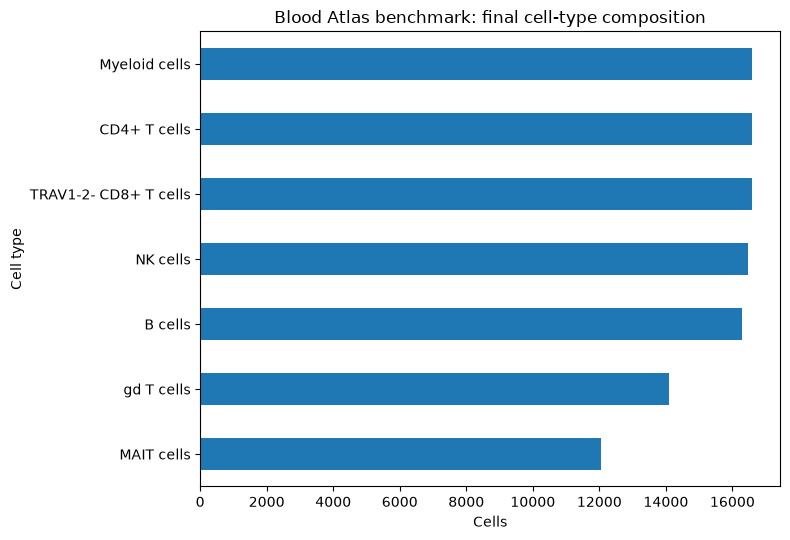

In [3]:
adata_backed = ad.read_h5ad(
    ADATA_PATH,
    backed="r",
)

overview = pd.DataFrame(
    [
        {
            "cells":
                adata_backed.n_obs,
            "HVGs":
                adata_backed.n_vars,
            "donors":
                adata_backed.obs[
                    "donor_id"
                ]
                .astype(str)
                .nunique(),
            "cell_types":
                adata_backed.obs[
                    "cell_type"
                ]
                .astype(str)
                .nunique(),
            "batches":
                adata_backed.obs[
                    "batch"
                ]
                .astype(str)
                .nunique(),
            "PCA_dims":
                adata_backed.obsm[
                    "X_pca"
                ].shape[1],
            "Harmony_dims":
                adata_backed.obsm[
                    "X_harmony"
                ].shape[1],
            "scVI_present":
                "X_scVI"
                in adata_backed.obsm,
        }
    ]
)

display(
    overview
)

assert (
    overview.loc[
        0,
        "scVI_present",
    ]
    is False
    or overview.loc[
        0,
        "scVI_present",
    ]
    == False
)

celltype_counts = (
    adata_backed.obs[
        "cell_type"
    ]
    .astype(str)
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(
    figsize=(
        8,
        5.5,
    )
)

celltype_counts.plot.barh(
    ax=ax
)

ax.set_xlabel(
    "Cells"
)
ax.set_ylabel(
    "Cell type"
)
ax.set_title(
    "Blood Atlas benchmark: "
    "final cell-type composition"
)

fig.tight_layout()
fig.savefig(
    FIG_DIR
    / "blood_atlas_celltype_composition.pdf",
    bbox_inches="tight",
)
plt.show()

if (
    hasattr(
        adata_backed,
        "file",
    )
    and adata_backed.file
    is not None
):
    adata_backed.file.close()

## PCA-derived UMAP (display artifact only)

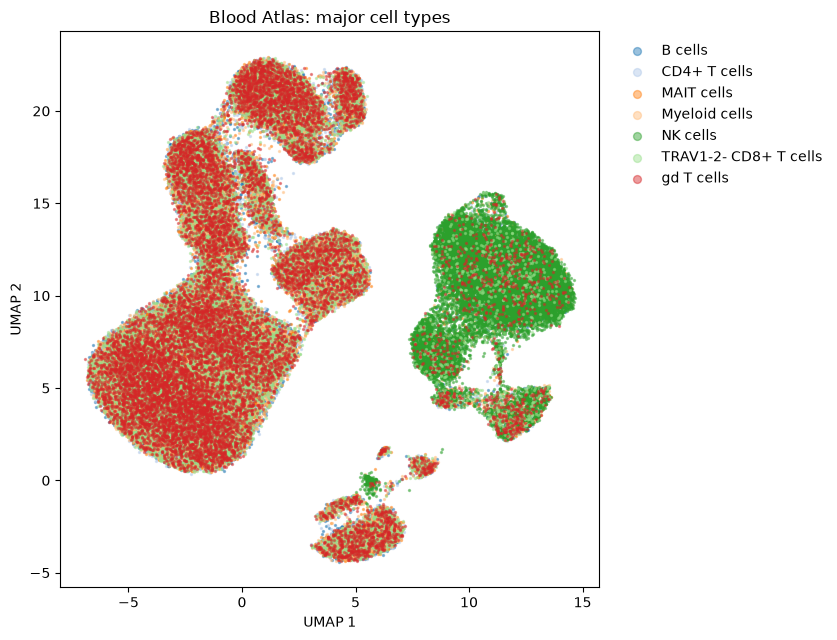

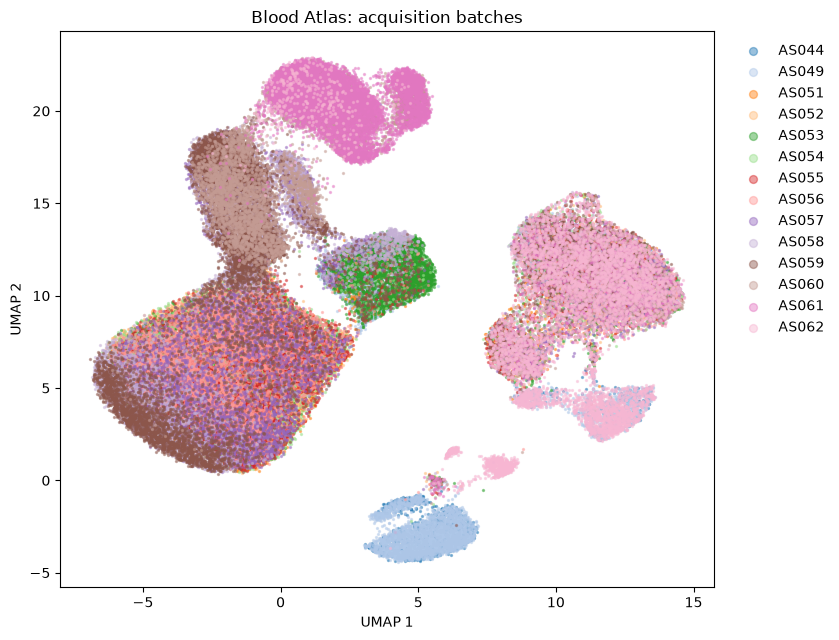

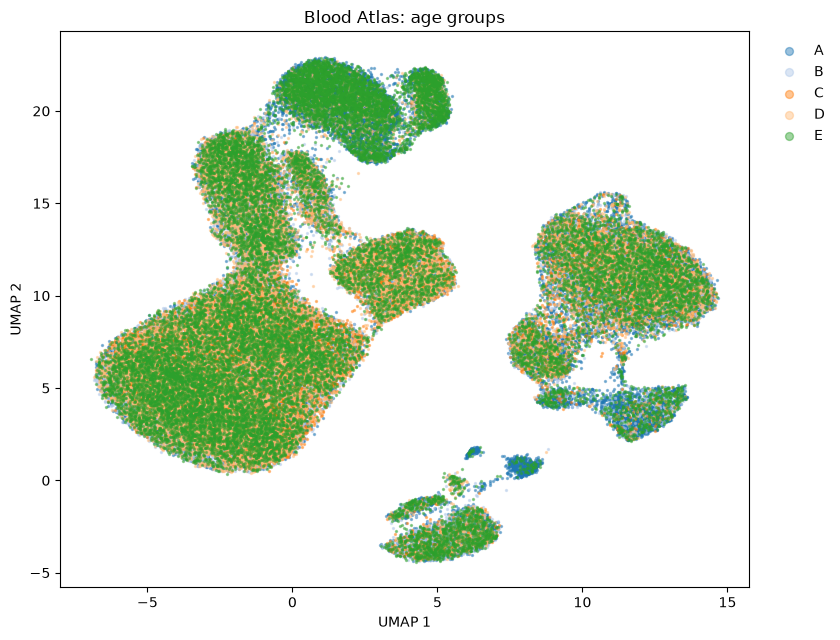

In [4]:
def get_or_make_umap():
    cache = (
        CACHE_DIR
        / "blood_atlas_umap_pca.csv"
    )

    if cache.exists():
        return pd.read_csv(
            cache,
            index_col=0,
        )

    adata = ad.read_h5ad(
        ADATA_PATH
    )

    sc.pp.neighbors(
        adata,
        use_rep="X_pca",
        random_state=42,
    )

    sc.tl.umap(
        adata,
        random_state=42,
    )

    coords = pd.DataFrame(
        adata.obsm[
            "X_umap"
        ],
        index=
            adata.obs_names
            .astype(str),
        columns=[
            "UMAP1",
            "UMAP2",
        ],
    )

    for col in [
        "cell_type",
        "batch",
        "age_group",
        "donor_id",
    ]:
        if col in adata.obs.columns:
            coords[col] = (
                adata.obs[
                    col
                ]
                .astype(str)
                .to_numpy()
            )

    coords.to_csv(
        cache
    )

    return coords

def plot_categorical_umap(
    coords,
    column,
    title,
    out_name,
):
    categories = sorted(
        coords[
            column
        ]
        .astype(str)
        .unique()
    )

    fig, ax = plt.subplots(
        figsize=(
            8.5,
            6.5,
        )
    )

    cmap = plt.get_cmap(
        "tab20",
        max(
            20,
            len(categories),
        ),
    )

    for i, label in enumerate(
        categories
    ):
        sub = coords[
            coords[
                column
            ].astype(str)
            == label
        ]

        ax.scatter(
            sub["UMAP1"],
            sub["UMAP2"],
            s=2,
            alpha=0.45,
            label=label,
            color=cmap(i),
            rasterized=True,
        )

    ax.set_xlabel(
        "UMAP 1"
    )
    ax.set_ylabel(
        "UMAP 2"
    )
    ax.set_title(
        title
    )

    ax.legend(
        frameon=False,
        bbox_to_anchor=(
            1.02,
            1,
        ),
        loc="upper left",
        markerscale=4,
    )

    fig.tight_layout()
    fig.savefig(
        FIG_DIR
        / out_name,
        bbox_inches="tight",
    )
    plt.show()

coords = get_or_make_umap()

plot_categorical_umap(
    coords,
    "cell_type",
    "Blood Atlas: major cell types",
    "blood_atlas_umap_celltype.pdf",
)

plot_categorical_umap(
    coords,
    "batch",
    "Blood Atlas: acquisition batches",
    "blood_atlas_umap_batch.pdf",
)

if "age_group" in coords.columns:
    plot_categorical_umap(
        coords,
        "age_group",
        "Blood Atlas: age groups",
        "blood_atlas_umap_age_group.pdf",
    )

## Random cell-level split vs donor-held-out evaluation

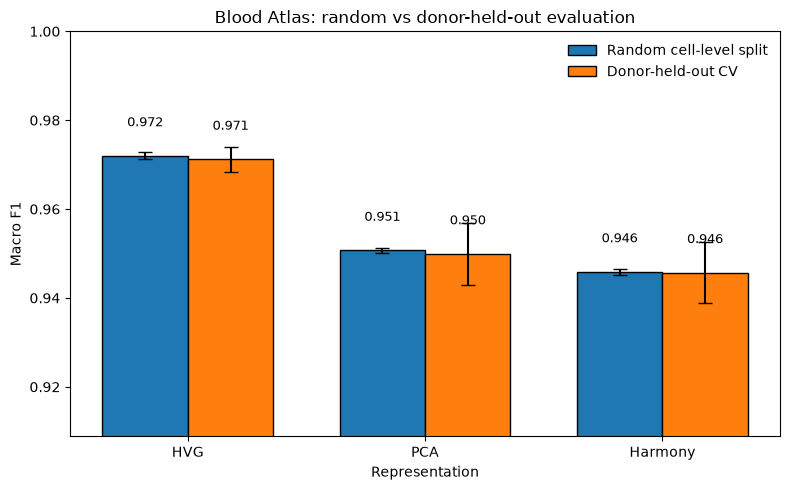

In [5]:
plot_random_vs_donor_cv(
    PRIMARY_DIR
    / "random_split"
    / "random_split_repeated_metrics.csv",
    PRIMARY_DIR
    / "donor_cv"
    / "metrics.csv",
    out_file=
        FIG_DIR
        / "blood_atlas_random_vs_donor.pdf",
    title=(
        "Blood Atlas: random vs "
        "donor-held-out evaluation"
    ),
)

plt.show()

## Batch-covariate sensitivity

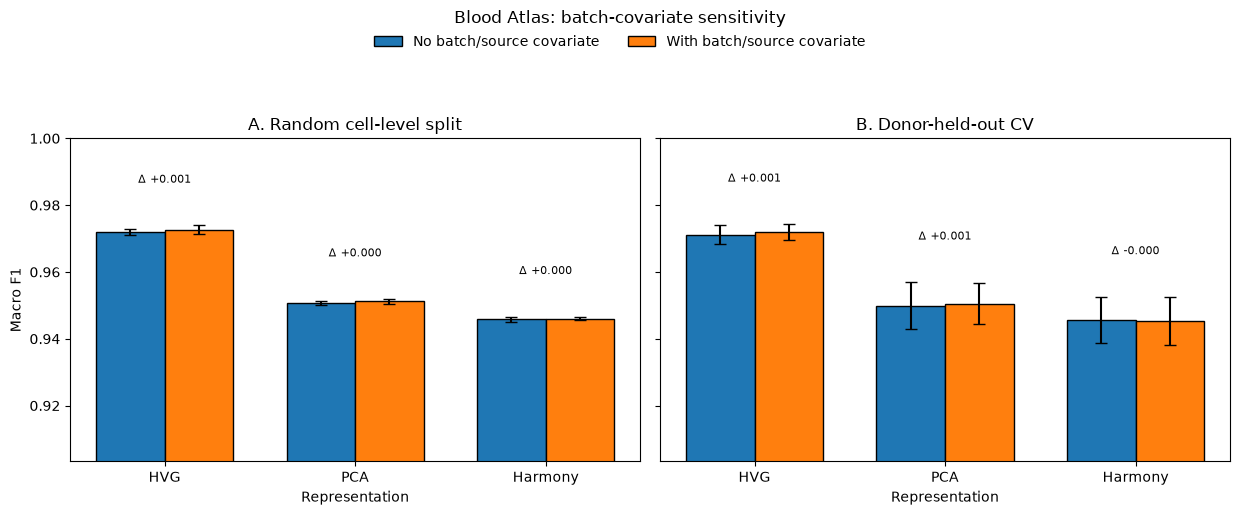

In [6]:
plot_batch_covariate_by_scheme(
    PRIMARY_DIR
    / "donor_cv"
    / "metrics.csv",
    BATCH_DIR
    / "donor_cv"
    / "metrics.csv",
    out_file=
        FIG_DIR
        / "blood_atlas_batch_covariate_sensitivity.pdf",
    title=(
        "Blood Atlas: "
        "batch-covariate sensitivity"
    ),
)

plt.show()

## Donor-ablation analysis

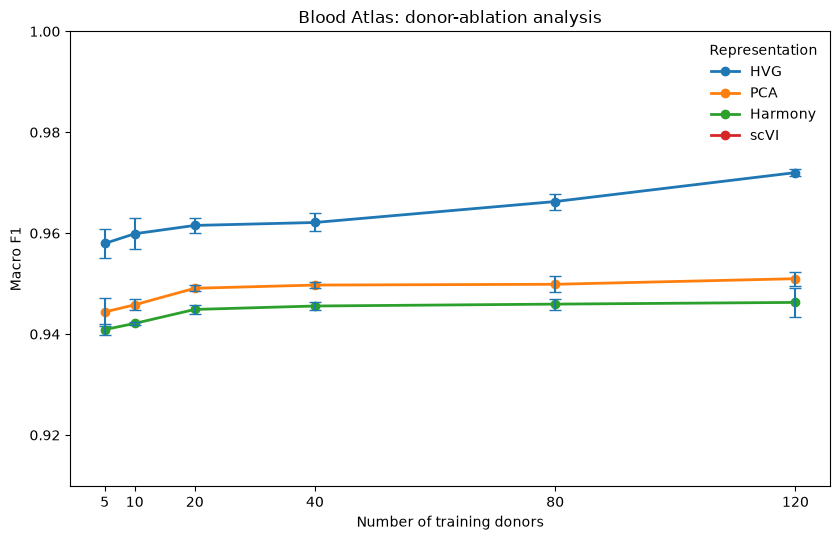

In [7]:
plot_donor_ablation(
    PRIMARY_DIR
    / "donor_ablation"
    / "donor_ablation_summary.csv",
    out_file=
        FIG_DIR
        / "blood_atlas_donor_ablation.pdf",
    title=(
        "Blood Atlas: "
        "donor-ablation analysis"
    ),
)

plt.show()

## Per-class donor-held-out F1

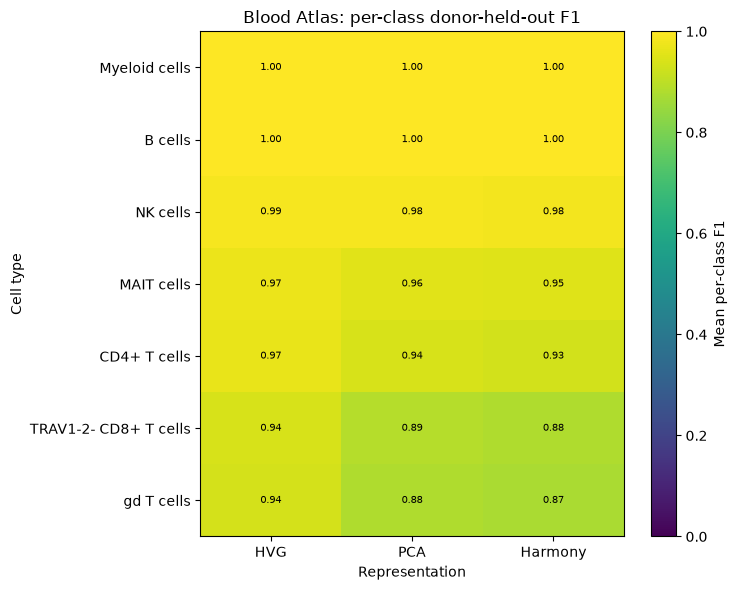

In [8]:
f1_matrix = (
    load_per_class_f1_matrix(
        PRIMARY_DIR
        / "donor_cv"
    )
)

# Explicitly retain only the three available representations.
f1_matrix = f1_matrix[
    [
        c
        for c in REP_ORDER
        if c in f1_matrix.columns
    ]
]

plot_per_class_f1_heatmap(
    f1_matrix,
    annotate=True,
    out_file=
        FIG_DIR
        / "blood_atlas_per_class_f1.pdf",
    title=(
        "Blood Atlas: "
        "per-class donor-held-out F1"
    ),
)

plt.show()

## Representative pooled donor-CV confusion matrix

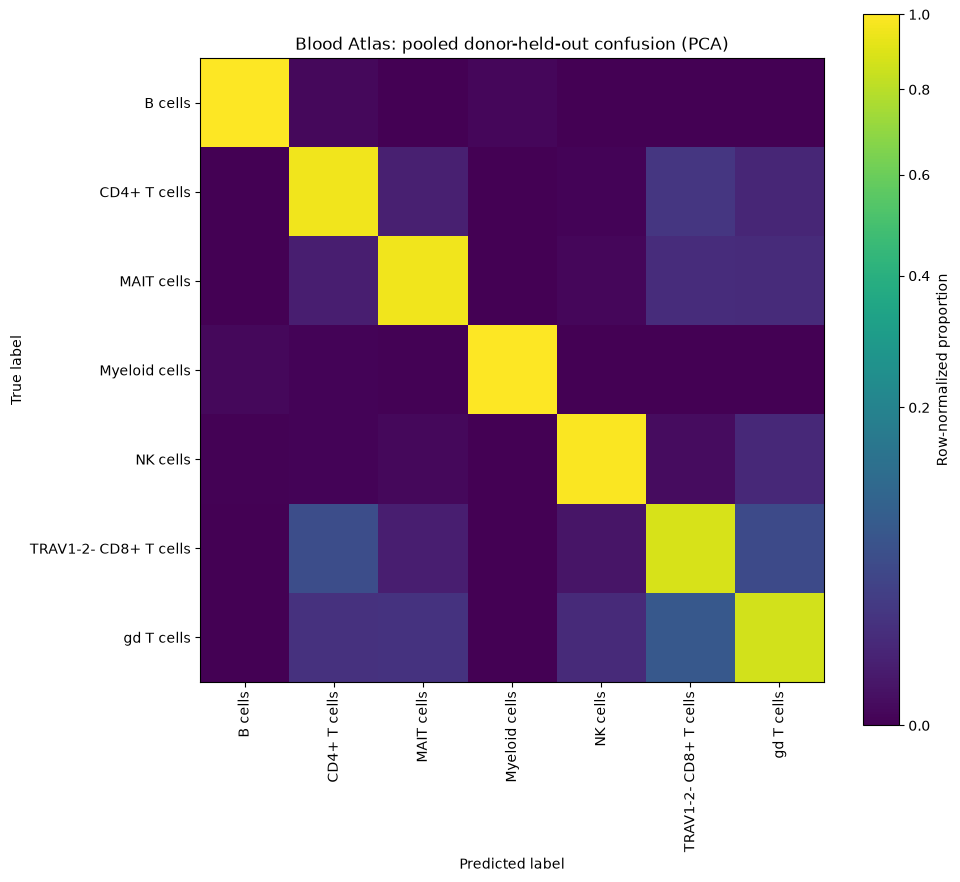

In [9]:
REPRESENTATIVE_REP = "pca"

pred_path = (
    PRIMARY_DIR
    / "donor_cv"
    / (
        f"donor_cv_"
        f"{REPRESENTATIVE_REP}"
        f"_all_predictions.csv"
    )
)

plot_confusion_matrix_from_predictions(
    pred_path,
    out_file=
        FIG_DIR
        / "blood_atlas_pca_confusion.pdf",
    title=(
        "Blood Atlas: pooled "
        "donor-held-out confusion "
        "(PCA)"
    ),
)

plt.show()

## Inflation-effect summary

,representation,random_macro_f1,donor_macro_f1,analysis,inflation_delta
0,harmony,0.945854,0.945673,No batch covariate,0.000181
1,hvg,0.971963,0.971180,No batch covariate,0.000783
2,pca,0.950683,0.949889,No batch covariate,0.000794
3,harmony,0.946047,0.945317,With batch covariate,0.000730
4,hvg,0.972583,0.971837,With batch covariate,0.000746
5,pca,0.951170,0.950481,With batch covariate,0.000689


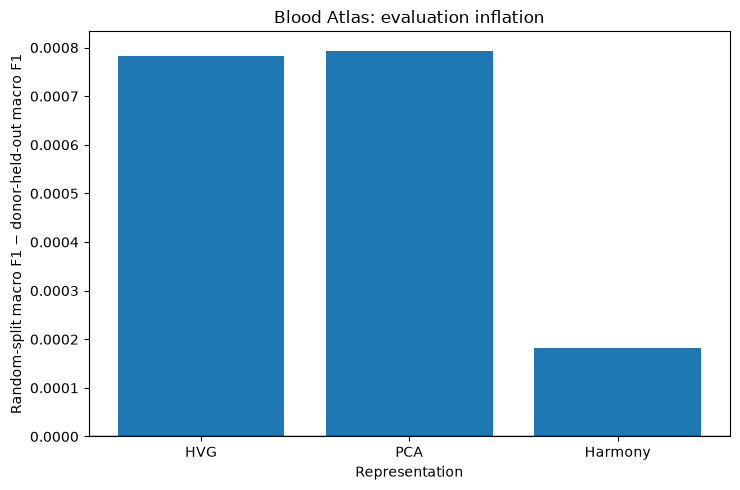

In [10]:
def inflation_table(
    result_dir,
    analysis_label,
):
    random_df = pd.read_csv(
        result_dir
        / "random_split"
        / "random_split_repeated_metrics.csv"
    )

    donor_df = pd.read_csv(
        result_dir
        / "donor_cv"
        / "metrics.csv"
    )

    random_mean = (
        random_df
        .groupby(
            "representation",
            as_index=False,
        )[
            "macro_f1"
        ]
        .mean()
        .rename(
            columns={
                "macro_f1":
                    "random_macro_f1"
            }
        )
    )

    donor_keep = (
        donor_df[
            [
                "representation",
                "macro_f1_mean",
            ]
        ]
        .rename(
            columns={
                "macro_f1_mean":
                    "donor_macro_f1"
            }
        )
    )

    out = random_mean.merge(
        donor_keep,
        on="representation",
        how="inner",
    )

    out["analysis"] = (
        analysis_label
    )

    out["inflation_delta"] = (
        out[
            "random_macro_f1"
        ]
        - out[
            "donor_macro_f1"
        ]
    )

    return out

inflation = pd.concat(
    [
        inflation_table(
            PRIMARY_DIR,
            "No batch covariate",
        ),
        inflation_table(
            BATCH_DIR,
            "With batch covariate",
        ),
    ],
    ignore_index=True,
)

assert set(
    inflation[
        "representation"
    ].unique()
).issubset(
    set(
        REP_ORDER
    )
)

display(
    inflation.sort_values(
        [
            "analysis",
            "representation",
        ]
    )
)

inflation.to_csv(
    CACHE_DIR
    / "blood_atlas_inflation_summary.csv",
    index=False,
)

primary = (
    inflation[
        inflation[
            "analysis"
        ]
        == "No batch covariate"
    ]
    .set_index(
        "representation"
    )
)

rep_order = [
    r
    for r in REP_ORDER
    if r in primary.index
]

vals = (
    primary
    .reindex(
        rep_order
    )[
        "inflation_delta"
    ]
)

fig, ax = plt.subplots(
    figsize=(
        7.5,
        5,
    )
)

ax.bar(
    np.arange(
        len(rep_order)
    ),
    vals,
)

ax.axhline(
    0,
    linewidth=1,
    color="black",
)

ax.set_xticks(
    np.arange(
        len(rep_order)
    )
)

ax.set_xticklabels(
    [
        DEFAULT_REP_LABELS.get(
            r,
            r,
        )
        for r in rep_order
    ]
)

ax.set_xlabel(
    "Representation"
)

ax.set_ylabel(
    "Random-split macro F1 − "
    "donor-held-out macro F1"
)

ax.set_title(
    "Blood Atlas: evaluation inflation"
)

fig.tight_layout()

fig.savefig(
    FIG_DIR
    / "blood_atlas_inflation_effect.pdf",
    bbox_inches="tight",
)

plt.show()